# Negentropic Coupling Framework - Interactive Demo

This notebook demonstrates the **Negentropic Coupling Framework (NCF)** simulation.

## Overview

NCF models how distributed systems self-stabilize through:
- **Entropy (H)**: Information uncertainty
- **Negentropy (N)**: Order measure (N = 1 - H/Hₘₐₓ)
- **Coherence (C)**: Bidirectional alignment
- **Entropy Velocity (v)**: Rate of change

---

## 1. Setup and Imports

In [1]:
import sys
import json
import numpy as np
import matplotlib.pyplot as plt

# Import NCF simulation module
sys.path.append('../models')
from NCF_simulation import NCFSimulation, run_simulation, plot_negentropy_evolution

print("NCF Simulation Module loaded successfully!")

['C:\\Python313\\python313.zip', 'C:\\Python313\\DLLs', 'C:\\Python313\\Lib', 'C:\\Python313', 'c:\\Users\\G\\Desktop\\Builds\\NegatropicCouplingTheory\\.venv', '', 'c:\\Users\\G\\Desktop\\Builds\\NegatropicCouplingTheory\\.venv\\Lib\\site-packages', '../models']
NCF Simulation Module loaded successfully!


## 2. Load Example Data

In [2]:
# Load example mesh configuration
with open('entropy_mesh_example.json', 'r') as f:
    example_data = json.load(f)

print("Example mesh configuration:")
print(f"  Nodes: {example_data['mesh']['nodes']}")
print(f"  Edges: {len(example_data['mesh']['edges'])}")
print(f"  Mode: {example_data['simulation_parameters']['mode']}")
print(f"  Steps: {example_data['simulation_parameters']['time_steps']}")

Example mesh configuration:
  Nodes: 5
  Edges: 10
  Mode: macro
  Steps: 10


## 3. Initialize Simulation

In [3]:
# Create simulation instance
n_nodes = example_data['mesh']['nodes']
n_edges = len(example_data['mesh']['edges'])

sim = NCFSimulation(n_nodes=n_nodes, n_edges=n_edges)

print(f"Initialized mesh with {n_nodes} nodes and {len(sim.edges)} edges")
print(f"\nSample edges: {sim.edges[:3]}")

Mesh initialized: 5 nodes, 10 edges
Initialized mesh with 5 nodes and 10 edges

Sample edges: [(1, 0), (4, 3), (0, 1)]


## 4. Compute Initial Metrics

In [4]:
# Compute metrics for first edge
edge = sim.edges[0]

entropy = sim.entropy_field(edge)
negentropy = sim.negentropic_index(edge)
coherence = sim.coherence(edge)
policy = sim.policy(edge)

print(f"Metrics for edge {edge}:")
print(f"  Shannon Entropy (H): {entropy:.4f}")
print(f"  Negentropic Index (N): {negentropy:.4f}")
print(f"  Coherence (C): {coherence:.4f}")
print(f"  Policy: {policy}")

Metrics for edge (1, 0):
  Shannon Entropy (H): 3.0361
  Negentropic Index (N): 0.0860
  Coherence (C): 0.9999
  Policy: defensive


## 5. Run Simulation

In [5]:
# Run simulation for specified steps
steps = example_data['simulation_parameters']['time_steps']
mode = example_data['simulation_parameters']['mode']

results = []
print(f"Running {steps} simulation steps...\n")

for step in range(steps):
    metrics = sim.evolve()
    results.append(metrics)
    
    if step % 2 == 0:  # Print every other step
        print(f"Step {step}: N={metrics['negentropy']:.3f}, "
              f"C={metrics['coherence']:.3f}, v={metrics['velocity']:.4f}")

print(f"\nSimulation complete!")

Running 10 simulation steps...

Step 0: N=0.051, C=0.604, v=0.0000
Step 2: N=0.021, C=0.599, v=0.0671
Step 4: N=0.015, C=0.600, v=0.0113
Step 6: N=0.015, C=0.601, v=-0.0049
Step 8: N=0.011, C=0.603, v=-0.0034

Simulation complete!


## 6. Visualize Results

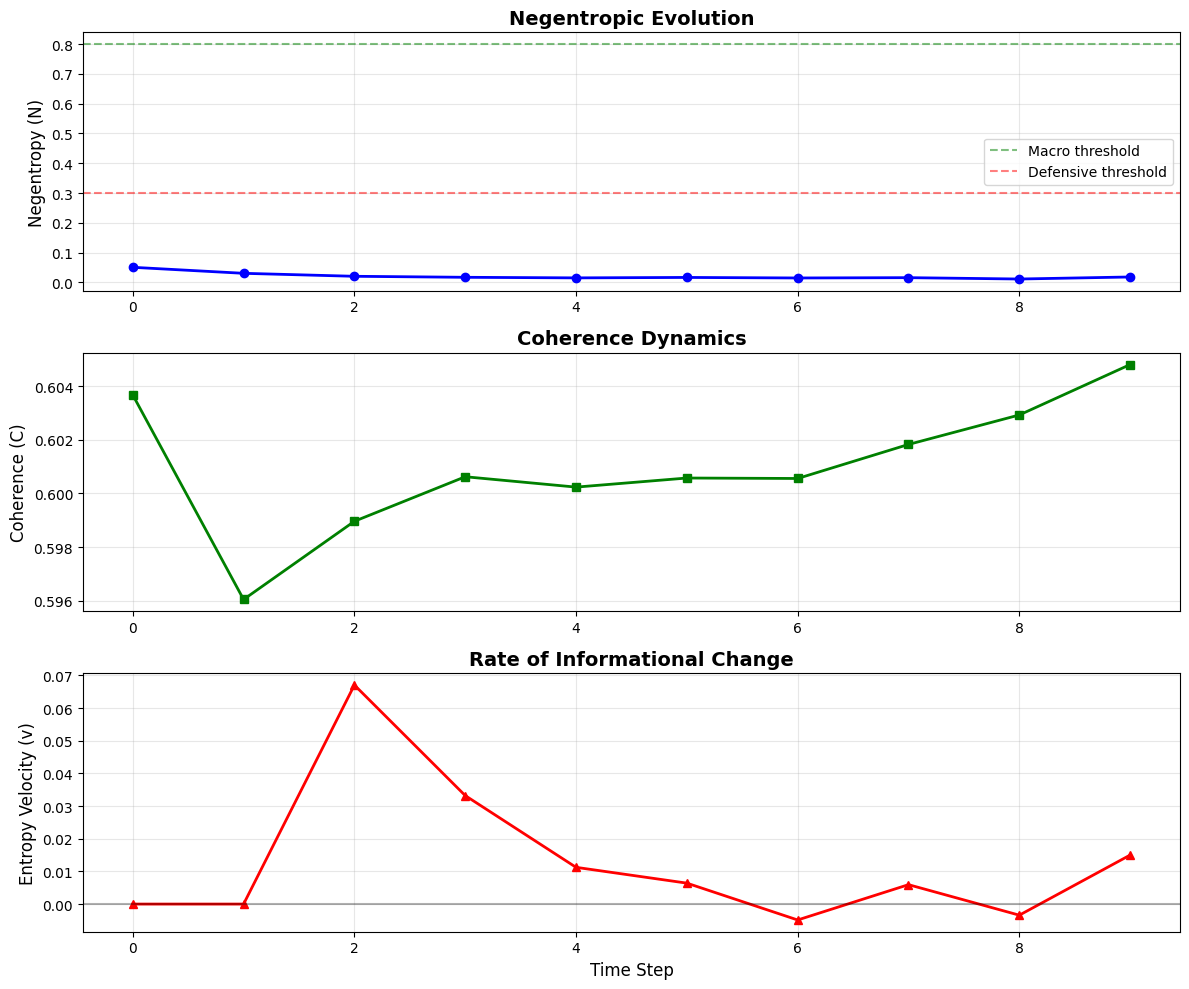


Visualization complete!


In [6]:
# Extract time series data
history = sim.get_history()
times = [h['time'] for h in history]
negentropies = [h['negentropy'] for h in history]
coherences = [h['coherence'] for h in history]
velocities = [h['velocity'] for h in history]

# Create multi-panel plot
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Plot 1: Negentropy
axes[0].plot(times, negentropies, 'b-', linewidth=2, marker='o')
axes[0].set_ylabel('Negentropy (N)', fontsize=12)
axes[0].set_title('Negentropic Evolution', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0.8, color='g', linestyle='--', alpha=0.5, label='Macro threshold')
axes[0].axhline(y=0.3, color='r', linestyle='--', alpha=0.5, label='Defensive threshold')
axes[0].legend()

# Plot 2: Coherence
axes[1].plot(times, coherences, 'g-', linewidth=2, marker='s')
axes[1].set_ylabel('Coherence (C)', fontsize=12)
axes[1].set_title('Coherence Dynamics', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Plot 3: Entropy Velocity
axes[2].plot(times, velocities, 'r-', linewidth=2, marker='^')
axes[2].set_xlabel('Time Step', fontsize=12)
axes[2].set_ylabel('Entropy Velocity (v)', fontsize=12)
axes[2].set_title('Rate of Informational Change', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].axhline(y=0, color='k', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nVisualization complete!")

## 7. Summary Statistics

In [7]:
# Compute summary statistics
final_n = negentropies[-1]
final_c = coherences[-1]
avg_n = np.mean(negentropies)
avg_c = np.mean(coherences)
max_v = max(abs(v) for v in velocities)

print("=" * 50)
print("SIMULATION SUMMARY")
print("=" * 50)
print(f"\nFinal State (t={steps-1}):")
print(f"  Negentropy: {final_n:.4f}")
print(f"  Coherence:  {final_c:.4f}")
print(f"\nAverages:")
print(f"  Mean Negentropy: {avg_n:.4f}")
print(f"  Mean Coherence:  {avg_c:.4f}")
print(f"  Max |Velocity|:  {max_v:.4f}")
print(f"\nSystem Regime:")

if final_n > 0.8 and final_c > 0.8:
    print("  → ORDERED-COHERENT (High throughput)")
elif final_n < 0.3 and final_c < 0.5:
    print("  → CHAOTIC (Defensive mode)")
else:
    print("  → TRANSITIONAL (Adaptive adjustment)")
print("\n" + "=" * 50)

SIMULATION SUMMARY

Final State (t=9):
  Negentropy: 0.0182
  Coherence:  0.6048

Averages:
  Mean Negentropy: 0.0211
  Mean Coherence:  0.6010
  Max |Velocity|:  0.0671

System Regime:
  → TRANSITIONAL (Adaptive adjustment)



## 8. Explore Edge-Level Details

In [8]:
# Analyze individual edges
print("Edge-Level Policies (final state):\n")

policy_counts = {"macro": 0, "balanced": 0, "defensive": 0}

for edge in sim.edges[:5]:  # Show first 5 edges
    n = sim.negentropic_index(edge)
    c = sim.coherence(edge)
    p = sim.policy(edge)
    policy_counts[p] += 1
    
    print(f"  Edge {edge}: N={n:.3f}, C={c:.3f} → Policy: {p}")

print(f"\nPolicy Distribution (all {len(sim.edges)} edges):")
for policy, count in policy_counts.items():
    print(f"  {policy}: {count}")

Edge-Level Policies (final state):

  Edge (1, 0): N=0.012, C=0.997 → Policy: defensive
  Edge (4, 3): N=0.020, C=0.020 → Policy: defensive
  Edge (0, 1): N=0.015, C=0.997 → Policy: defensive
  Edge (2, 4): N=0.017, C=0.980 → Policy: defensive
  Edge (3, 2): N=0.024, C=0.024 → Policy: defensive

Policy Distribution (all 10 edges):
  macro: 0
  balanced: 0
  defensive: 5


In [9]:
# Canonical scenario JSON output with metadata for Electron pipeline
import json, hashlib, time, sys

# Example scenario data (replace with your real mesh/initial_state)
scenario_core = {
    "mesh": {
        "nodes": 5,
        "edges": [[0,1],[1,2],[2,3],[3,4],[4,0]]
    },
    "initial_state": {
        "probability_distributions": {
            "[0, 1]": [0.2,0.2,0.2,0.2,0.2],
            "[1, 2]": [0.1,0.3,0.3,0.2,0.1],
            "[2, 3]": [0.25,0.25,0.25,0.15,0.1],
            "[3, 4]": [0.2,0.2,0.2,0.2,0.2],
            "[4, 0]": [0.2,0.2,0.2,0.2,0.2]
        }
    }
}

def scenario_metadata(scenario, source_path):
    raw = json.dumps(scenario, sort_keys=True).encode()
    return {
        "checksum": hashlib.sha256(raw).hexdigest(),
        "size": len(raw),
        "timestamp": time.time(),
        "source": source_path
    }

scenario = dict(scenario_core)
scenario["metadata"] = scenario_metadata(scenario_core, "models/NCF_simulation.py")

print(json.dumps(scenario, indent=2))

{
  "mesh": {
    "nodes": 5,
    "edges": [
      [
        0,
        1
      ],
      [
        1,
        2
      ],
      [
        2,
        3
      ],
      [
        3,
        4
      ],
      [
        4,
        0
      ]
    ]
  },
  "initial_state": {
    "probability_distributions": {
      "[0, 1]": [
        0.2,
        0.2,
        0.2,
        0.2,
        0.2
      ],
      "[1, 2]": [
        0.1,
        0.3,
        0.3,
        0.2,
        0.1
      ],
      "[2, 3]": [
        0.25,
        0.25,
        0.25,
        0.15,
        0.1
      ],
      "[3, 4]": [
        0.2,
        0.2,
        0.2,
        0.2,
        0.2
      ],
      "[4, 0]": [
        0.2,
        0.2,
        0.2,
        0.2,
        0.2
      ]
    }
  },
  "metadata": {
    "checksum": "0d6ea6cdf318629733602ba70441f7181dafbd6957ad4840fb3ed8bcdf38da3a",
    "size": 312,
    "timestamp": 1765225523.2160976,
    "source": "models/NCF_simulation.py"
  }
}


## 9. Theoretical Interpretation

### Key Insights:

1. **Negentropy (N)** measures order:
   - N → 1: Highly ordered, predictable
   - N → 0: Maximum entropy, chaotic

2. **Coherence (C)** measures alignment:
   - High C: Bidirectional agreement
   - Low C: Asymmetric information flow

3. **Entropy Velocity (v)** tracks change:
   - v > 0: Increasing uncertainty
   - v < 0: Decreasing uncertainty (ordering)

4. **Policy Mapping**:
   - `macro`: High-throughput, zero-copy frames (N > 0.8)
   - `balanced`: Moderate throughput (0.3 ≤ N ≤ 0.8)
   - `defensive`: Conservative, ACK-based (N < 0.3)

### Mathematical Foundation:

The system evolves according to:

```
x(t+1) = F(x(t)) + G(N(t), C(t), V(t)) x(t)
```

where **G** is the adaptive coupling operator that adjusts inter-node influence based on measured information fields.

## 10. Negentropic Basin Operator

This demo treats a 1-D signal (any array of magnitudes) as a probability field, then searches for a coupling that *reduces* Shannon entropy. The entropy drop (`epiplexity`) is a proxy for finding a stable basin: positive values mean we found a lower-entropy configuration. The returned `stable_state` is the coupling value that achieved the minimum in the bounded search.

How to read it:
- `orig_ent` vs `final_ent`: before/after entropy.
- `epiplexity`: entropy reduction (negentropic gain). Larger positive means stronger basin capture.
- `stable_state`: coupling that minimized entropy within the bounds.

You can feed in any distribution: mesh probabilities, FFT power spectra, or wavelet band energies. Keep the search bounds and coupling strength moderate to avoid saturation.


### Relativity analogy (why the well pulls)
- Treat the bounded search (lo, hi) as a curved potential surface; entropy is the height function.
- Coupling strength acts like mass-energy: larger coupling warps the surface more and steepens the descent toward a basin.
- The stable_state is the geodesic-like extremum where entropy is minimized under the soft constraints (penalties = curvature pressure keeping us off singular boundaries).
- If the surface is tilted hard toward a boundary, the optimum will slide near that edge; increasing penalties or narrowing bounds flattens curvature near the rim so you see an interior minimum instead.

### Epiplexity as core metric
- Formal definition: $$\mathcal{E} = H_{\text{before}} - H_{\text{after}}$$ (units: bits; realized negentropic work per coupling application).
- Interpretation: basin depth / stability gained; complements negentropy by focusing on *delta* rather than absolute order.
- Surface in diagnostics:
  - FlowController: log `epiplexity`, `stable_state`, and `negentropic_gain` per step.
  - PolicyConsole: show basin depth (epiplexity), pressure vector (stable_state), and width/sensitivity derived from penalty response.
  - Scenario diagnostics: aggregate mean/peak epiplexity across edges/nodes.
- Next vectorized step (outline): replace the scalar update `signal + coupling_strength * x` with `signal + coupling_strength * (W @ x_vec)` to capture topology-weighted coupling and multi-basin regimes.

### Vectorized NBO sketch
- Replace scalar coupling with topology-weighted coupling: `signal + coupling_strength * (W @ x_vec)`
- `x_vec`: per-node/edge policy pressures; `W`: trust/topology weights (rows sum can be 1 for stability).
- Output metrics to surface: `epiplexity` (basin depth), `stable_state` (pressure), `negentropic_gain`, and a simple width proxy (entropy curvature from penalties or finite differences).
- Wire to console: depth → glow, stable_state → arrow bias, width → confidence ring.

In [71]:
import json
import numpy as np


def shannon_entropy(p: np.ndarray) -> float:
    p = np.asarray(p, dtype=float)
    p = np.clip(p, 1e-12, None)
    p = p / p.sum()
    return -np.sum(p * np.log2(p))


def ks_negentropy(p: np.ndarray) -> float:
    # Kolmogorov-Shannon negentropy: N = 1 - H / Hmax
    p = np.asarray(p, dtype=float)
    p = np.clip(p, 1e-12, None)
    p = p / p.sum()
    h = shannon_entropy(p)
    hmax = np.log2(len(p)) if len(p) > 0 else 1.0
    return max(0.0, min(1.0, 1.0 - h / hmax))


def bounded_minimize(f, lo: float = -1.0, hi: float = 1.0, tol: float = 1e-5, max_iter: int = 200):
    # Simple golden-section search (no scipy dependency)
    phi = (1 + 5 ** 0.5) / 2
    invphi = 1 / phi
    invphi2 = invphi ** 2
    a, b = lo, hi
    h = b - a
    if h <= tol:
        return (a + b) / 2
    n = int(np.ceil(np.log(tol / h) / np.log(invphi)))
    c = a + invphi2 * h
    d = a + invphi * h
    fc = f(c)
    fd = f(d)
    for _ in range(min(n, max_iter)):
        if fc < fd:
            b, d, fd = d, c, fc
            h = invphi * h
            c = a + invphi2 * h
            fc = f(c)
        else:
            a, c, fc = c, d, fd
            h = invphi * h
            d = a + invphi * h
            fd = f(d)
    return (a + b) / 2


def simulate_entropy_gravity(signal: np.ndarray, coupling_strength: float = 0.5, lo: float = -1.0, hi: float = 1.0):
    # Normalize to probability distribution
    signal = np.asarray(signal, dtype=float)
    signal = np.clip(signal, 1e-12, None)
    base_prob = signal / signal.sum()
    orig_ent = shannon_entropy(base_prob)
    orig_neg = ks_negentropy(base_prob)

    min_prob = 1e-9
    boundary_margin = 0.02
    bound_penalty = 0.3

    def functional(x: float) -> float:
        coupled = np.clip(signal + coupling_strength * x, 1e-12, None)
        p = coupled / coupled.sum()
        h = shannon_entropy(p)
        penalty = 0.0
        if p.min() < min_prob:
            penalty += bound_penalty
        proximity = min(x - lo, hi - x)
        if proximity < boundary_margin:
            penalty += bound_penalty * (boundary_margin - proximity) / boundary_margin
        return h + penalty

    x_star = bounded_minimize(functional, lo=lo, hi=hi, tol=1e-5)

    coupled = np.clip(signal + coupling_strength * x_star, 1e-12, None)
    p_star = coupled / coupled.sum()
    final_ent = shannon_entropy(p_star)
    final_neg = ks_negentropy(p_star)
    epiplexity = orig_ent - final_ent  # Entropy reduction
    negentropic_gain = final_neg - orig_neg
    return {
        "orig_ent": orig_ent,
        "final_ent": final_ent,
        "orig_neg": orig_neg,
        "final_neg": final_neg,
        "epiplexity": epiplexity,
        "negentropic_gain": negentropic_gain,
        "stable_state": float(x_star),
        "bounds": (lo, hi),
        "coupling_strength": coupling_strength,
    }


np.random.seed(1)
trace = np.random.rand(20, 5) ** 2  # skewed distribution
baseline = simulate_entropy_gravity(trace.flatten(), coupling_strength=0.5, lo=-1.0, hi=1.0)
print(json.dumps(baseline, indent=2))

couplings = [0.2, 0.5, 0.8]
rows = []
for c in couplings:
    res = simulate_entropy_gravity(trace.flatten(), coupling_strength=c, lo=-1.0, hi=1.0)
    rows.append({
        "coupling": c,
        "stable_state": res["stable_state"],
        "final_ent": res["final_ent"],
        "final_neg": res["final_neg"],
        "epiplexity": res["epiplexity"],
        "negentropic_gain": res["negentropic_gain"],
    })
print("Sweep (bounds fixed to [-1,1]):")
for r in rows:
    print(
        f"c={r['coupling']:.2f}, stable_state={r['stable_state']:.4f}, "
        f"epiplexity={r['epiplexity']:.4f}, neg_gain={r['negentropic_gain']:.4f}, "
        f"final_ent={r['final_ent']:.4f}, final_neg={r['final_neg']:.4f}"
)

{
  "orig_ent": 5.980964955849549,
  "final_ent": 4.453723078304935,
  "orig_neg": 0.0997750726370934,
  "final_neg": 0.329647880524646,
  "epiplexity": 1.527241877544614,
  "negentropic_gain": 0.2298728078875526,
  "stable_state": -0.9799973234721158,
  "bounds": [
    -1.0,
    1.0
  ],
  "coupling_strength": 0.5
}
Sweep (bounds fixed to [-1,1]):
c=0.20, stable_state=-0.9800, epiplexity=0.5822, neg_gain=0.0876, final_ent=5.3988, final_neg=0.1874
c=0.50, stable_state=-0.9800, epiplexity=1.5272, neg_gain=0.2299, final_ent=4.4537, final_neg=0.3296
c=0.80, stable_state=-0.9800, epiplexity=2.7302, neg_gain=0.4109, final_ent=3.2507, final_neg=0.5107


In [74]:
# Vectorized negentropic basin operator (NBO) with soft interior penalties
# Uses raw-entropy curvature for basin width and provides both scalar and per-dimension solves.

def nbo_vectorized(
    signal: np.ndarray,
    W: np.ndarray,
    x_vec: np.ndarray,
    coupling_strength: float = 0.5,
    lo: float = -0.3,
    hi: float = 0.3,
    min_prob: float = 1e-6,
    boundary_margin: float = 0.05,
    bound_penalty: float = 1.0,
    ridge: float = 1e-3,
    coord_sweeps: int = 4,
):
    signal = np.asarray(signal, dtype=float)
    W = np.asarray(W, dtype=float)
    x_vec = np.asarray(x_vec, dtype=float)

    # topology-weighted baseline field
    base_field = signal + coupling_strength * (W @ x_vec)
    base_field = np.clip(base_field, 1e-12, None)

    base_prob = base_field / base_field.sum()
    orig_ent = shannon_entropy(base_prob)
    orig_neg = ks_negentropy(base_prob)

    def penalty_term(offsets: np.ndarray) -> float:
        penalty = 0.0
        c = np.clip(base_field + coupling_strength * offsets, 1e-12, None)
        p = c / c.sum()
        if p.min() < min_prob:
            penalty += bound_penalty * (min_prob - p.min()) / min_prob
        proximity = np.minimum(offsets - lo, hi - offsets).min()
        if proximity < boundary_margin:
            penalty += bound_penalty * (boundary_margin - proximity) / boundary_margin
        if ridge:
            penalty += ridge * float(np.sum(offsets ** 2))
        return penalty

    def entropy_with_penalty(offsets: np.ndarray) -> float:
        c = np.clip(base_field + coupling_strength * offsets, 1e-12, None)
        p = c / c.sum()
        h = shannon_entropy(p)
        return h + penalty_term(offsets)

    # Scalar offset search (legacy path)
    def entropy_at_scalar_offset(x_offset: float) -> float:
        return entropy_with_penalty(np.full_like(base_field, x_offset))

    x_star_scalar = bounded_minimize(entropy_at_scalar_offset, lo=lo, hi=hi, tol=1e-4)

    # Raw-entropy curvature (no penalties) at the scalar optimum
    def raw_entropy_at_scalar_offset(x_offset: float) -> float:
        c = np.clip(base_field + coupling_strength * x_offset, 1e-12, None)
        p = c / c.sum()
        return shannon_entropy(p)

    delta = 0.01
    h_center = raw_entropy_at_scalar_offset(x_star_scalar)
    h_left = raw_entropy_at_scalar_offset(np.clip(x_star_scalar - delta, lo, hi))
    h_right = raw_entropy_at_scalar_offset(np.clip(x_star_scalar + delta, lo, hi))
    curvature_raw = max((h_left - 2 * h_center + h_right) / (delta ** 2), 1e-9)
    basin_width_raw = 1.0 / np.sqrt(curvature_raw)

    # Penalty-only curvature (sensitivity to constraints)
    pen_center = penalty_term(np.full_like(base_field, x_star_scalar))
    pen_left = penalty_term(np.full_like(base_field, np.clip(x_star_scalar - delta, lo, hi)))
    pen_right = penalty_term(np.full_like(base_field, np.clip(x_star_scalar + delta, lo, hi)))
    curvature_penalty = max((pen_left - 2 * pen_center + pen_right) / (delta ** 2), 1e-9)
    basin_width_penalty = 1.0 / np.sqrt(curvature_penalty)

    # Per-dimension bounded solves (multiple coordinate descent sweeps)
    offsets = np.zeros_like(base_field)
    for _ in range(coord_sweeps):
        for i in range(len(offsets)):
            def f_i(xi: float) -> float:
                trial = offsets.copy()
                trial[i] = xi
                return entropy_with_penalty(trial)
            offsets[i] = bounded_minimize(f_i, lo=lo, hi=hi, tol=1e-4)

    # Per-node attribution: H(base) - H(base with only offset_i applied)
    def entropy_single_offset(idx: int, offset_val: float) -> float:
        trial = np.zeros_like(base_field)
        trial[idx] = offset_val
        c = np.clip(base_field + coupling_strength * trial, 1e-12, None)
        p = c / c.sum()
        return shannon_entropy(p)

    epiplexity_per_node = np.array(
        [orig_ent - entropy_single_offset(i, offsets[i]) for i in range(len(offsets))]
    )

    # Evaluate outputs for scalar path
    coupled_scalar = np.clip(base_field + coupling_strength * x_star_scalar, 1e-12, None)
    p_scalar = coupled_scalar / coupled_scalar.sum()
    final_ent_scalar = shannon_entropy(p_scalar)
    final_neg_scalar = ks_negentropy(p_scalar)

    # Evaluate outputs for vector path
    coupled_vec = np.clip(base_field + coupling_strength * offsets, 1e-12, None)
    p_vec = coupled_vec / coupled_vec.sum()
    final_ent_vec = shannon_entropy(p_vec)
    final_neg_vec = ks_negentropy(p_vec)

    return {
        "orig_ent": orig_ent,
        "orig_neg": orig_neg,
        "scalar": {
            "final_ent": final_ent_scalar,
            "final_neg": final_neg_scalar,
            "epiplexity": orig_ent - final_ent_scalar,
            "negentropic_gain": final_neg_scalar - orig_neg,
            "stable_state": float(x_star_scalar),
            "basin_width_raw": basin_width_raw,
            "basin_width_penalty": basin_width_penalty,
        },
        "vector": {
            "final_ent": final_ent_vec,
            "final_neg": final_neg_vec,
            "epiplexity": orig_ent - final_ent_vec,
            "negentropic_gain": final_neg_vec - orig_neg,
            "stable_state_vector": offsets.tolist(),
            "epiplexity_per_node": epiplexity_per_node.tolist(),
            "epiplexity_weights": (
                epiplexity_per_node / (np.abs(epiplexity_per_node).sum() + 1e-12)
            ).tolist(),
        },
        "bounds": (lo, hi),
        "coupling_strength": coupling_strength,
    }

# Example with non-uniform topology and pressures (replace with your real data)
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)
n = 12
W_raw = rng.random((n, n))
W = W_raw / W_raw.sum(axis=1, keepdims=True)
x_vec = rng.normal(loc=0.0, scale=0.15, size=n)
signal_sample = trace.flatten()[:n]

demo = nbo_vectorized(
    signal_sample,
    W,
    x_vec,
    coupling_strength=0.5,
    lo=-0.3,
    hi=0.3,
    bound_penalty=1.0,
    coord_sweeps=4,
)
scalar = demo["scalar"]
vector = demo["vector"]

summary = {
    "orig_ent": demo["orig_ent"],
    "orig_neg": demo["orig_neg"],
    "scalar": {
        "epiplexity": scalar["epiplexity"],
        "negentropic_gain": scalar["negentropic_gain"],
        "stable_state": scalar["stable_state"],
        "basin_width_raw": scalar["basin_width_raw"],
        "basin_width_penalty": scalar["basin_width_penalty"],
    },
    "vector": {
        "epiplexity": vector["epiplexity"],
        "negentropic_gain": vector["negentropic_gain"],
        "final_neg": vector["final_neg"],
    },
}
print(json.dumps(summary, indent=2))

weights = np.array(vector["epiplexity_weights"])
idx = np.argsort(np.abs(weights))[::-1][: min(5, len(weights))]
print("Top contributors (by |weight|):")
for rank, i in enumerate(idx, 1):
    print(
        f"{rank:>2}. node {i:02d} weight={weights[i]:+.4f} "
        f"ep={vector['epiplexity_per_node'][i]:+.6f}"
    )

# Uncomment for full dump
# print(json.dumps(demo, indent=2))


{
  "orig_ent": 2.846038056527127,
  "orig_neg": 0.20611776107710633,
  "scalar": {
    "epiplexity": -0.00021908526780345383,
    "negentropic_gain": -6.111228994987172e-05,
    "stable_state": 1.9832088405495217e-05,
    "basin_width_raw": 0.055528452960140605,
    "basin_width_penalty": 0.009999990616257582
  },
  "vector": {
    "epiplexity": 1.0770736249186847,
    "negentropic_gain": 0.30044208961795815,
    "final_neg": 0.5065598506950645
  }
}
Top contributors (by |weight|):
 1. node 07 weight=+0.1756 ep=+0.152608
 2. node 03 weight=+0.1621 ep=+0.140914
 3. node 08 weight=+0.1414 ep=+0.122933
 4. node 00 weight=+0.1343 ep=+0.116730
 5. node 10 weight=+0.1075 ep=+0.093435


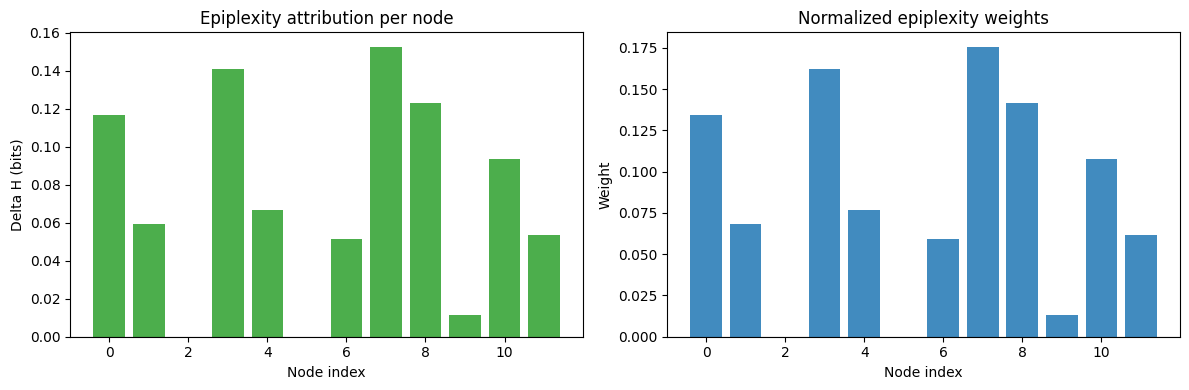

In [76]:
import matplotlib.pyplot as plt

# Plot per-node epiplexity attribution
weights = np.array(vector["epiplexity_weights"])
epiplexity = np.array(vector["epiplexity_per_node"])
indices = np.arange(len(epiplexity))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ["tab:green" if v >= 0 else "tab:red" for v in epiplexity]
axes[0].bar(indices, epiplexity, color=colors, alpha=0.85)
axes[0].axhline(0, color="k", linewidth=0.8, alpha=0.6)
axes[0].set_title("Epiplexity attribution per node")
axes[0].set_xlabel("Node index")
axes[0].set_ylabel("Delta H (bits)")

weight_colors = ["tab:blue" if v >= 0 else "tab:orange" for v in weights]
axes[1].bar(indices, weights, color=weight_colors, alpha=0.85)
axes[1].axhline(0, color="k", linewidth=0.8, alpha=0.6)
axes[1].set_title("Normalized epiplexity weights")
axes[1].set_xlabel("Node index")
axes[1].set_ylabel("Weight")

plt.tight_layout()
plt.show()


**Citation:**
> gsknnft (2025). The Negentropic Coupling Framework (NCF) v1.0.  
> SigilNet Research Series.  
> https://github.com/gsknnft/NegatropicCouplingTheory
